# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 8     |  |
| :-------------|:-------------|
| Koen Gort| 6574963 |
| Thijmen Haverkorn van Rijsewijk | 6500897 |
| Siemen Spek| 6579531 |
|---|---|
| Planning Groep: 8     |Tijdstip / Tijdspanne  |
| sanity checks| 11.15 |
| bouw een condensator | 12.45 |
| Pauze 1| 12.45 - 13.45 |
| calibratie meting| 15.15 |
| bouw een capacitieve condensator| 16.30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schets_condensator.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def vlakkeplaat(A,l,epsilon):
    C = (A*epsilon)/l
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
# C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]
epsilon0 = 8.8541878188*10**-12
epsilon_lucht = 1.00056
C = vlakkeplaat(0.1**2,0.00101,3*epsilon0)


print(f"Berekende capaciteit plaatcondensator groep 8 is {C:.2e} F")
print(f'Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F ')


Berekende capaciteit plaatcondensator groep 8 is 2.63e-10 F
Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F 


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](meetopstelling_condensator.jpg)
![scope meting 2](oscilloscoop_scherm.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 8| 263 pF | 1.3 V | 0.95 V | 190 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen_synthese.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die het niveau van een laag water meet, door middel van een bak water tussen deze twee platen. Als de hoeveelheid water in deze bak dan toeneemt, zal de permittiviteit eveneens toenemen.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schets_afmetingen.jpg)

In de verwachte plot spreken we over de percentage water van de inhoud van de doos. Dit is omdat we nog niet de inhoud van de doos precies weten. Deze moet nog geeikt worden en daarna gelabeld. 

Daarnaast staat op de y-as E_r, dit is omdat we de andere parameter (A en d) nog niet gedefineerd zijn. Maar E_r is rechteveredig met C dus de plot geeft een juiste indicatie.

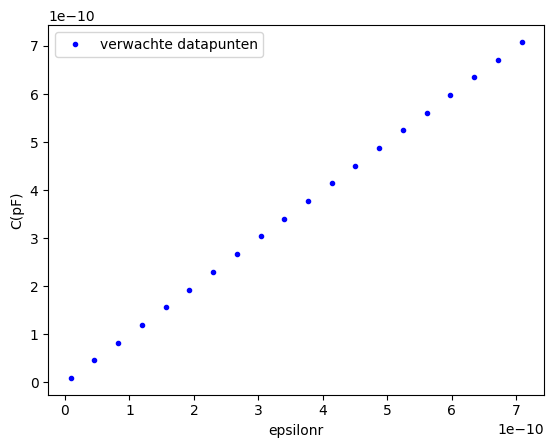

[8.85418782e-12 4.56689687e-11 8.24837497e-11 1.19298531e-10
 1.56113312e-10 1.92928092e-10 2.29742873e-10 2.66557654e-10
 3.03372435e-10 3.40187216e-10 3.77001997e-10 4.13816778e-10
 4.50631559e-10 4.87446340e-10 5.24261121e-10 5.61075902e-10
 5.97890683e-10 6.34705464e-10 6.71520245e-10 7.08335026e-10]


In [3]:
epsilonr = epsilon0 * np.linspace(1,80,20)
d = 0.01
A = 0.1**2
c = vlakkeplaat(A,d,epsilonr)
plt.figure()
plt.plot(epsilonr, c, 'b.', label="verwachte datapunten")
plt.legend()
plt.xlabel("epsilonr")
plt.ylabel("C(pF)") 
plt.show()
print(c)


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 8 | 50 |
| gemiddelde capaciteit| 358 |1740 |
| maximale capaciteit| 708 |2200 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](sensoren_in_actie.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

0.00025303632318576856


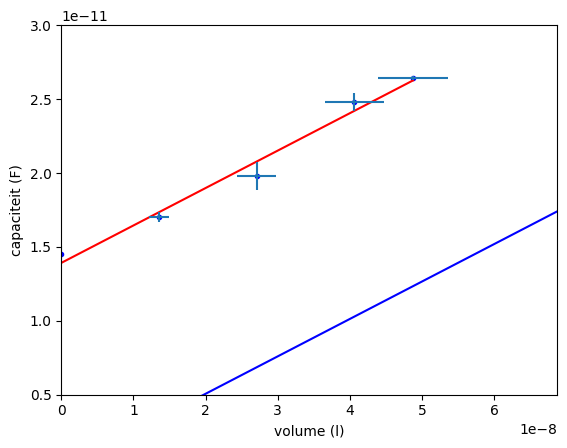

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
lengte = 0.087 
hoogte = 0.089 
Inhoud = lengte * hoogte * d

capaciteit = np.array([14.5,17.0,19.8,24.8,26.4])*10**-12
volume = np.array([0,0.25,0.5,0.75,0.9])*10**-3*(Inhoud*0.7)

def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function, volume, capaciteit)
x_fit = np.linspace(0, max(volume), 300)
y_fit = function(x_fit,*values)
print(values[0])

capaciteit_err = np.abs(function(volume,*values)-capaciteit)
volume_err = 0.1 * volume

verwacht_volume = c/values[0]
v_verwacht = np.array([verwacht_volume[0],verwacht_volume[10],verwacht_volume[-1]])
C_verwacht = np.array([c[0],c[10],c[-1]])
popt, pcov = curve_fit(function,v_verwacht,C_verwacht)
x_nieuw = np.linspace(0,max(v_verwacht),300)


plt.figure()
plt.plot(volume, capaciteit,'b.')
plt.plot(x_nieuw, function(x_nieuw,*popt),'b-')
plt.xlim(0,max(volume+2*10**-8))
plt.ylim(0.5e-11,0.3e-10)
plt.plot(x_fit,y_fit,'r-')
plt.errorbar(volume,capaciteit,capaciteit_err,volume_err, fmt = 'none')
plt.xlabel(r'volume (l)')
plt.ylabel(r'capaciteit (F)')
plt.show()



## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Ons oppervlakte vergroten door beter positioneren.
* Maken gebruik van waarden die zijn aangegeven op de doos waardoor volume metingen accurater worden.
* Beter berekend hoeveel van totale volume met water wordt gevuld

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](meetopstelling_einde.jpg)

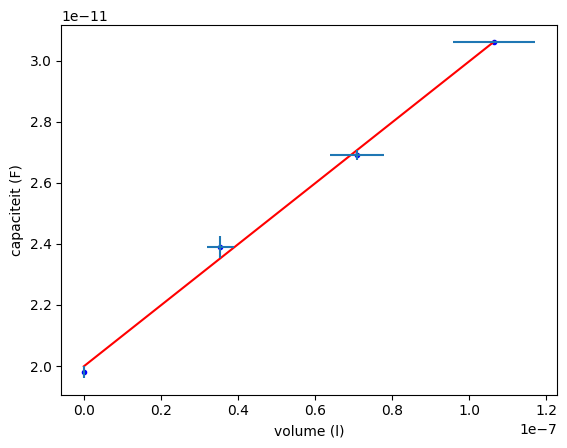

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
dikte_nieuw = 0.0174

lengte = 0.087 
hoogte = 0.089 
Inhoud = lengte * hoogte * dikte_nieuw

capaciteit = np.array([19.8,23.9,26.9, 30.6])*10**-12
volume = np.array([0,1/3,2/3,1])*10**-3*(Inhoud*0.7894737)

def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function, volume, capaciteit)
x_fit = np.linspace(0, max(volume), 300)
y_fit = function(x_fit,*values)


capaciteit_err = np.abs(function(volume,*values)-capaciteit)
volume_err = 0.1 * volume

plt.figure()
plt.plot(volume, capaciteit,'b.')
plt.plot(x_fit,y_fit,'r-')
plt.errorbar(volume,capaciteit,capaciteit_err,volume_err, fmt = 'none')
plt.xlabel(r'volume (l)')
plt.ylabel(r'capaciteit (F)')
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Deze methode is een bewezen goede manier om het volume van water in een bak te bepalen. Er is sprake van een linear verband wat overeen komt met de theorie, C is recht evenredig met Epsilonr. De fit valt binnen de meetonzekerheden. De verwachtte maximale capaciteit lag veel hoger dan de daadwerkelijke maximale capaciteit, dit komt doordat onder andere niet het hele oppervlak is gebruikt, er sprake is van meerdere materialen dan alleen water en lucht (plastic randen) en omdat de afstand tussen de twee platen kleiner is dan verwacht van te voren. Ook stonden de platen niet precies loodrecht tegenover elkaar waardoor het oppervlakte afneemt. Voor verder onderzoek kan er veel verbetering worden behaald in een nauwkeurigere waterpercentage bepaling en er kunnen meer meetpunten behaald worden. 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

leerdoel 1:

![scope meting 1](meetopstelling_condensator.jpg)
![scope meting 2](oscilloscoop_scherm.jpg)

In [6]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
# C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]
epsilon0 = 8.8541878188*10**-12
epsilon_lucht = 1.00056
C = vlakkeplaat(0.1**2,0.00101,3*epsilon0)


print(f"Berekende capaciteit plaatcondensator groep 8 is {C:.2e} F")
print(f'Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F ')

Berekende capaciteit plaatcondensator groep 8 is 2.63e-10 F
Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F 


In [7]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def vlakkeplaat(A,l,epsilon):
    C = (A*epsilon)/l
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

Leerdoel 2:

![scope meting 1](meetopstelling_condensator.jpg)
![meting 1](sensoren_in_actie.jpg)

In [8]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def vlakkeplaat(A,l,epsilon):
    C = (A*epsilon)/l
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [9]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
# C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]
epsilon0 = 8.8541878188*10**-12
epsilon_lucht = 1.00056
C = vlakkeplaat(0.1**2,0.00101,3*epsilon0)


print(f"Berekende capaciteit plaatcondensator groep 8 is {C:.2e} F")
print(f'Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F ')

Berekende capaciteit plaatcondensator groep 8 is 2.63e-10 F
Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F 


Leerdoel 3:

0.00025303632318576856


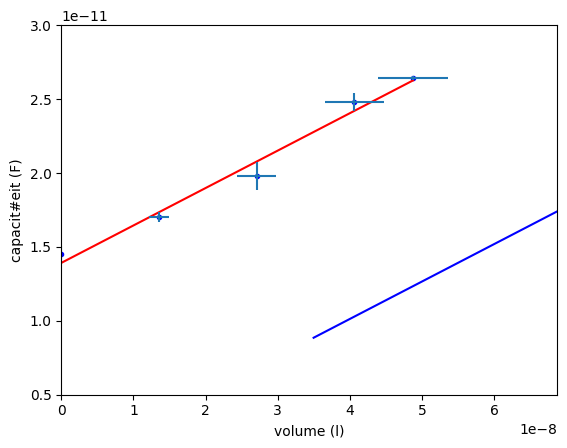

In [10]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
lengte = 0.087 
hoogte = 0.089 
Inhoud = lengte * hoogte * d

capaciteit = np.array([14.5,17.0,19.8,24.8,26.4])*10**-12
volume = np.array([0,0.25,0.5,0.75,0.9])*10**-3*(Inhoud*0.7)

def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function, volume, capaciteit)
x_fit = np.linspace(0, max(volume), 300)
y_fit = function(x_fit,*values)
print(values[0])

capaciteit_err = np.abs(function(volume,*values)-capaciteit)
volume_err = 0.1 * volume

verwacht_volume = c/values[0]

plt.figure()
plt.plot(volume, capaciteit,'b.')
plt.plot(verwacht_volume,c,'b-')
plt.xlim(0,max(volume+2*10**-8))
plt.ylim(0.5e-11,0.3e-10)
plt.plot(x_fit,y_fit,'r-')
plt.errorbar(volume,capaciteit,capaciteit_err,volume_err, fmt = 'none')
plt.xlabel(r'volume (l)')
plt.ylabel(r'capacit#eit (F)')
plt.show()


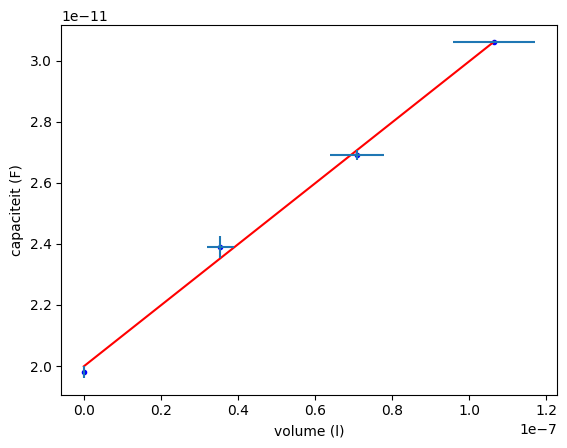

In [11]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
dikte_nieuw = 0.0174

lengte = 0.087 
hoogte = 0.089 
Inhoud = lengte * hoogte * dikte_nieuw

capaciteit = np.array([19.8,23.9,26.9, 30.6])*10**-12
volume = np.array([0,1/3,2/3,1])*10**-3*(Inhoud*0.7894737)

def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function, volume, capaciteit)
x_fit = np.linspace(0, max(volume), 300)
y_fit = function(x_fit,*values)


capaciteit_err = np.abs(function(volume,*values)-capaciteit)
volume_err = 0.1 * volume

plt.figure()
plt.plot(volume, capaciteit,'b.')
plt.plot(x_fit,y_fit,'r-')
plt.errorbar(volume,capaciteit,capaciteit_err,volume_err, fmt = 'none')
plt.xlabel(r'volume (l)')
plt.ylabel(r'capaciteit (F)')
plt.show()